In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/rsna-pneumonia-detection-challenge/stage_2_sample_submission.csv
/kaggle/input/competitions/rsna-pneumonia-detection-challenge/stage_2_detailed_class_info.csv
/kaggle/input/competitions/rsna-pneumonia-detection-challenge/GCP Credits Request Link - RSNA.txt
/kaggle/input/competitions/rsna-pneumonia-detection-challenge/stage_2_train_labels.csv
/kaggle/input/competitions/rsna-pneumonia-detection-challenge/stage_2_train_images/c3b05294-29be-46e4-8a51-96fd211e4ca5.dcm
/kaggle/input/competitions/rsna-pneumonia-detection-challenge/stage_2_train_images/6a6ed2c5-d179-4c19-aac7-0d70eb87e024.dcm
/kaggle/input/competitions/rsna-pneumonia-detection-challenge/stage_2_train_images/06550cfd-e9d5-415e-bae9-3146329ed9e6.dcm
/kaggle/input/competitions/rsna-pneumonia-detection-challenge/stage_2_train_images/ef9eee29-6bdd-41da-ae40-9473592a9d5c.dcm
/kaggle/input/competitions/rsna-pneumonia-detection-challenge/stage_2_train_images/c5dfc1a7-4669-42ce-af9f-62c3d8322049.dcm
/kaggle/i

# SETUP

# Imports y rutas

In [2]:
import os

RUTA_DATOS   = '/kaggle/input/competitions/rsna-pneumonia-detection-challenge'
RUTA_OUTPUTS = '/kaggle/working'

In [3]:
!pip install pydicom --quiet

# Instalar librerías

In [4]:
import numpy as np
import pandas as pd
import pydicom
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from tqdm.notebook import tqdm
import cv2
import os

# Verificar estructura
compruebo qué archivos y carpetas trae el dataset antes de explorar

In [5]:
for elemento in sorted(os.listdir(RUTA_DATOS)):
    ruta = os.path.join(RUTA_DATOS, elemento)
    if os.path.isdir(ruta):
        n = len(os.listdir(ruta))
        print(f'[dir]  {elemento}/ — {n} archivos')
    else:
        print(f'[file] {elemento}')

[file] GCP Credits Request Link - RSNA.txt
[file] stage_2_detailed_class_info.csv
[file] stage_2_sample_submission.csv
[dir]  stage_2_test_images/ — 3000 archivos
[dir]  stage_2_train_images/ — 26684 archivos
[file] stage_2_train_labels.csv


#  Leer CSV de labels

In [6]:
df_labels = pd.read_csv(f'{RUTA_DATOS}/stage_2_train_labels.csv')
print(df_labels.shape)
df_labels.head(10)

(30227, 6)


,patientId,x,y,width,height,Target
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,NaN,NaN,NaN,NaN,0
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,NaN,NaN,NaN,NaN,0
2,00322d4d-1c29-4943-afc9-b6754be640eb,NaN,NaN,NaN,NaN,0
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,NaN,NaN,NaN,NaN,0
4,00436515-870c-4b36-a041-de91049b9ab4,264.0,152.0,213.0,379.0,1
5,00436515-870c-4b36-a041-de91049b9ab4,562.0,152.0,256.0,453.0,1
6,00569f44-917d-4c86-a842-81832af98c30,NaN,NaN,NaN,NaN,0
7,006cec2e-6ce2-4549-bffa-eadfcd1e9970,NaN,NaN,NaN,NaN,0
8,00704310-78a8-4b38-8475-49f4573b2dbb,323.0,577.0,160.0,104.0,1
9,00704310-78a8-4b38-8475-49f4573b2dbb,695.0,575.0,162.0,137.0,1


# EXPLORACIÓN DEL DATASET

# Distribución de clases

In [7]:
# verifico el balance entre positivos y negativos porque afecta directamente a la estrategia de entrenamiento
conteo = df_labels.groupby('Target')['patientId'].nunique()
print(conteo)
print(f'\nratio positivos: {conteo[1] / conteo.sum():.2%}')

Target
0    20672
1     6012
Name: patientId, dtype: int64

ratio positivos: 22.53%


# Clases detalladas

No Lung Opacity / Not Normal: Sin opacidad pulmonar / No normal (significa que la radiografía muestra alguna anomalía, pero no es la opacidad típica de una neumonía; podría ser otra condición médica).

Lung Opacity: Opacidad pulmonar (este es el grupo positivo para neumonía, donde se ven las manchas blanquecinas en los pulmones).

Normal: Normal (pulmones completamente sanos y sin hallazgos extraños).

In [8]:
# cargo el csv con las 3 clases para entender cuántos casos son anómalos pero sin neumonía
df_clases = pd.read_csv(f'{RUTA_DATOS}/stage_2_detailed_class_info.csv')
print(df_clases['class'].value_counts())

class
No Lung Opacity / Not Normal    11821
Lung Opacity                     9555
Normal                           8851
Name: count, dtype: int64


# Ejemplo DICOM

In [9]:
# leo un dicom de ejemplo para entender su estructura antes de planificar la conversión a PNG
ruta_train = f'{RUTA_DATOS}/stage_2_train_images'
ejemplo_id  = df_labels['patientId'].iloc[0]
dcm         = pydicom.dcmread(f'{ruta_train}/{ejemplo_id}.dcm')

print(f'shape:             {dcm.pixel_array.shape}')
print(f'dtype:             {dcm.pixel_array.dtype}')
print(f'min/max:           {dcm.pixel_array.min()} / {dcm.pixel_array.max()}')
print(f'PhotometricInterp: {dcm.PhotometricInterpretation}')

shape:             (1024, 1024)
dtype:             uint8
min/max:           0 / 245
PhotometricInterp: MONOCHROME2


Esto describe las propiedades técnicas de una de las imágenes radiográficas (en formato DICOM)

MONOCHROME2 $\rightarrow$ Interpretación fotométrica: Esto es clave en medicina. Significa que el 0 es negro y el valor más alto es blanco.Nota: Si dijera MONOCHROME1, la imagen estaría invertida (el 0 sería blanco y el 255 negro, como un negativo fotográfico). 

Al ser MONOCHROME2, puedes visualizarla directamente de forma normal: los huesos y zonas densas se verán blancos/claros, y el aire (los pulmones sanos) se verá negro/oscuro.

# Visualizar ejemplos con bounding box

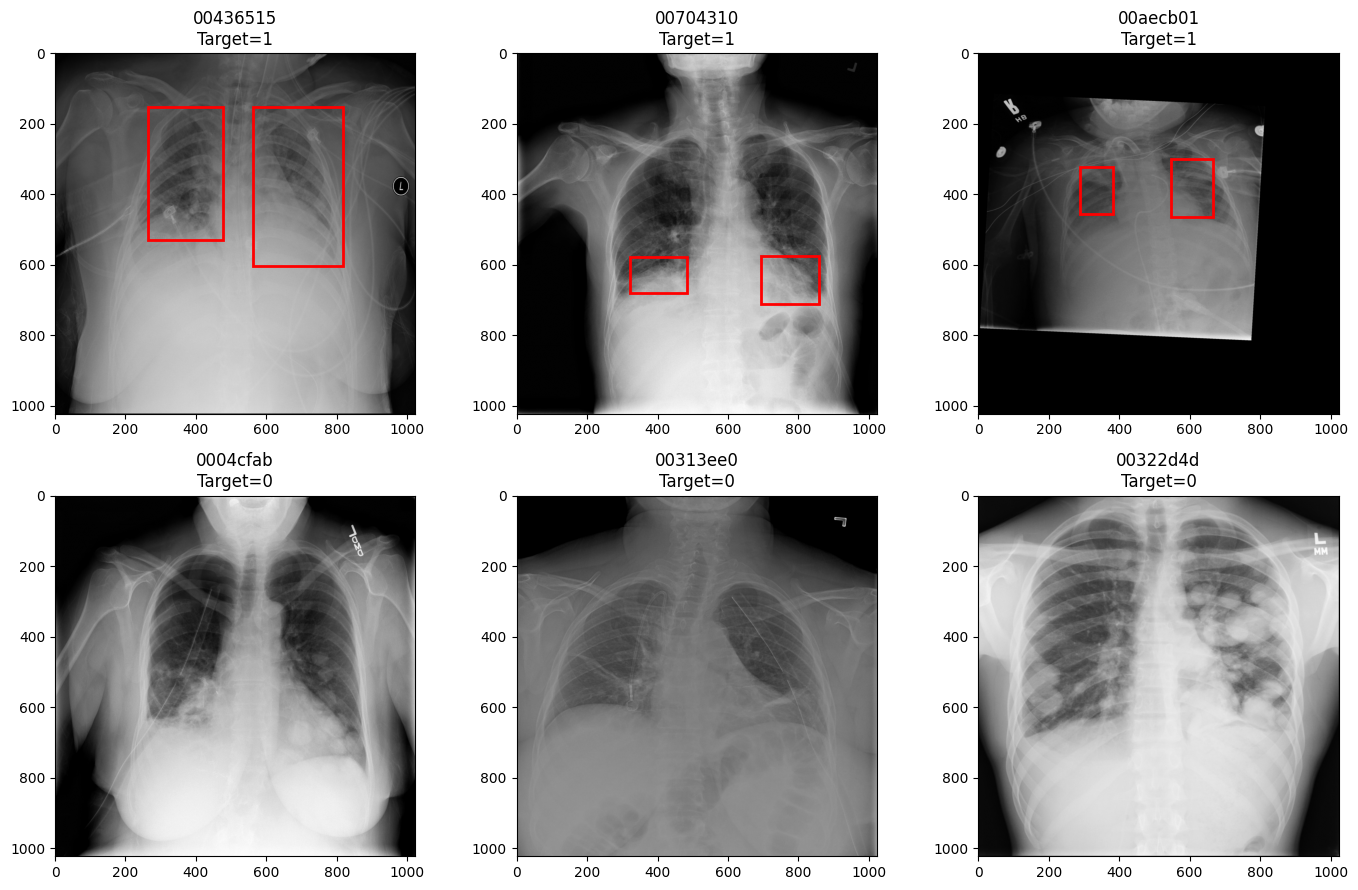

In [10]:
# muestro casos positivos y negativos para entender visualmente cómo se ve la neumonía en la radiografía
def mostrar_caso(patient_id, ax):
    dcm   = pydicom.dcmread(f'{ruta_train}/{patient_id}.dcm')
    img   = dcm.pixel_array
    filas = df_labels[df_labels['patientId'] == patient_id]
    ax.imshow(img, cmap='gray')
    ax.set_title(f'{patient_id[:8]}\nTarget={filas["Target"].iloc[0]}')
    for _, fila in filas.iterrows():
        if fila['Target'] == 1:
            rect = patches.Rectangle(
                (fila['x'], fila['y']), fila['width'], fila['height'],
                linewidth=2, edgecolor='red', facecolor='none'
            )
            ax.add_patch(rect)

positivos = df_labels[df_labels['Target'] == 1]['patientId'].unique()[:3]
negativos = df_labels[df_labels['Target'] == 0]['patientId'].unique()[:3]

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for ax, pid in zip(axes[0], positivos):
    mostrar_caso(pid, ax)
for ax, pid in zip(axes[1], negativos):
    mostrar_caso(pid, ax)
plt.tight_layout()
plt.show()

Estás viendo un análisis exploratorio de datos (EDA) donde comparan ejemplos positivos de neumonía frente a negativos. Vamos a desglosarlo en dos partes:

1. La fila de arriba: Target = 1 (Casos Positivos)
Estas tres radiografías pertenecen a pacientes que sí tienen neumonía (opacidad pulmonar).

Las cajas rojas (Bounding Boxes): Son las etiquetas (ground truth) que los radiólogos expertos dibujaron a mano. Le indican a tu modelo la ubicación exacta de la infección.

Fíjate que la neumonía suele aparecer en ambos pulmones o en zonas específicas, viéndose como manchas blancas difusas (opacidades) donde normalmente debería verse oscuro (aire).

El objetivo de tu IA: Cuando le pases una imagen nueva, tu modelo tendrá que ser capaz de adivinar y dibujar esas mismas cajas rojas en el lugar correcto.

2. La fila de abajo: Target = 0 (Casos Negativos)
Estas tres radiografías pertenecen a pacientes que no tienen opacidad por neumonía.

Sin cajas rojas: Como el objetivo es detectar opacidad pulmonar por neumonía, aquí no hay ninguna caja que dibujar.

El truco médico (¡Ojo con la tercera imagen!): Mira la imagen de abajo a la derecha (00322d4d). Tiene unas manchas blancas gigantescas y muy marcadas en el pulmón derecho (a tu izquierda). Cualquiera pensaría que está enfermo, ¡y lo está! Pero el médico determinó que no es la opacidad típica de una neumonía (podría ser un tumor, líquido u otra patología).

Esto demuestra por qué el reto es difícil: tu modelo tiene que aprender a diferenciar la opacidad de la neumonía de otras manchas o problemas pulmonares.

¿Qué te dice esto para tu código?
Que estás ante un problema clásico de Detección de Objetos. Tu modelo no solo tendrá que decir "sí o no" (Target 1 o 0), sino que si dice "sí", tendrá que dar las coordenadas de esas cajitas rojas.


# Análisis de bounding boxes

total bounding boxes: 9555
pacientes con 1 box:  2614
pacientes con 2+ box: 3398

            x       y   width  height
count  9555.0  9555.0  9555.0  9555.0
mean    394.0   366.8   218.5   329.3
std     204.6   148.9    59.3   157.8
min       2.0     2.0    40.0    45.0
25%     207.0   249.0   177.0   203.0
50%     324.0   365.0   217.0   298.0
75%     594.0   478.5   259.0   438.0
max     835.0   881.0   528.0   942.0


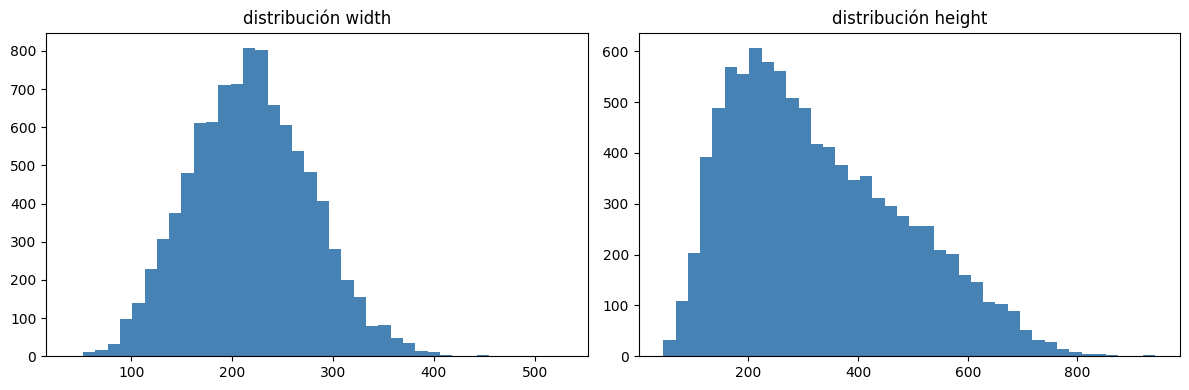

In [11]:
# analizo tamaños y distribución de las boxes para entender qué escala tienen los focos de neumonía
df_pos = df_labels[df_labels['Target'] == 1].copy()

print(f'total bounding boxes: {len(df_pos)}')
print(f'pacientes con 1 box:  {(df_pos.groupby("patientId").size() == 1).sum()}')
print(f'pacientes con 2+ box: {(df_pos.groupby("patientId").size() > 1).sum()}')
print()
print(df_pos[['x', 'y', 'width', 'height']].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_pos['width'],  bins=40, color='steelblue')
axes[0].set_title('distribución width')
axes[1].hist(df_pos['height'], bins=40, color='steelblue')
axes[1].set_title('distribución height')
plt.tight_layout()
plt.show()

In [12]:
!git clone --branch fran https://github.com/franciscofdzfer/RSNAPneumonia

Cloning into 'RSNAPneumonia'...
remote: Enumerating objects: 12, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 12 (delta 3), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (12/12), 526.77 KiB | 9.41 MiB/s, done.
Resolving deltas: 100% (3/3), done.


In [13]:
pacientes_multi = df_pos.groupby('patientId').size()
paciente_multi  = pacientes_multi[pacientes_multi > 1].index[0]

print(df_labels[df_labels['patientId'] == paciente_multi])

                                  patientId      x      y  width  height  \
28990  000db696-cf54-4385-b10b-6b16fbb3f985  316.0  318.0  170.0   478.0   
28991  000db696-cf54-4385-b10b-6b16fbb3f985  660.0  375.0  146.0   402.0   

       Target  
28990       1  
28991       1  


# PREPROCESADO

#  Función de conversión DICOM → PNG

In [14]:

# defino la función de conversión antes del bucle para poder testearla sobre pocas imágenes primero
def dicom_a_png(ruta_dcm, ruta_png, tamanio=512):
    dcm = pydicom.dcmread(ruta_dcm)
    img = dcm.pixel_array.astype(np.float32)

    # invierto si la imagen está en MONOCHROME1 (blanco=aire, negro=tejido)
    if dcm.PhotometricInterpretation == 'MONOCHROME1':
        img = img.max() - img

    # normalizo a 0-255
    img = (img - img.min()) / (img.max() - img.min() + 1e-6) * 255
    img = img.astype(np.uint8)

    # convierto a 3 canales para compatibilidad con modelos ImageNet
    img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    img = cv2.resize(img, (tamanio, tamanio))

    cv2.imwrite(ruta_png, img)

# Test de conversión sobre 5 imágenes

In [15]:

# pruebo la función sobre 5 imágenes antes de lanzar el bucle completo con las 26k
ruta_png_train = os.path.join(RUTA_OUTPUTS, 'png_train')
os.makedirs(ruta_png_train, exist_ok=True)

ids_test = df_labels['patientId'].unique()[:5]

for pid in ids_test:
    ruta_dcm = f'{ruta_train}/{pid}.dcm'
    ruta_png = f'{ruta_png_train}/{pid}.png'
    dicom_a_png(ruta_dcm, ruta_png)
    print(f'convertido: {pid}.png — existe: {os.path.exists(ruta_png)}')

convertido: 0004cfab-14fd-4e49-80ba-63a80b6bddd6.png — existe: True
convertido: 00313ee0-9eaa-42f4-b0ab-c148ed3241cd.png — existe: True
convertido: 00322d4d-1c29-4943-afc9-b6754be640eb.png — existe: True
convertido: 003d8fa0-6bf1-40ed-b54c-ac657f8495c5.png — existe: True
convertido: 00436515-870c-4b36-a041-de91049b9ab4.png — existe: True


# Verificar visualmente los PNGs convertidos

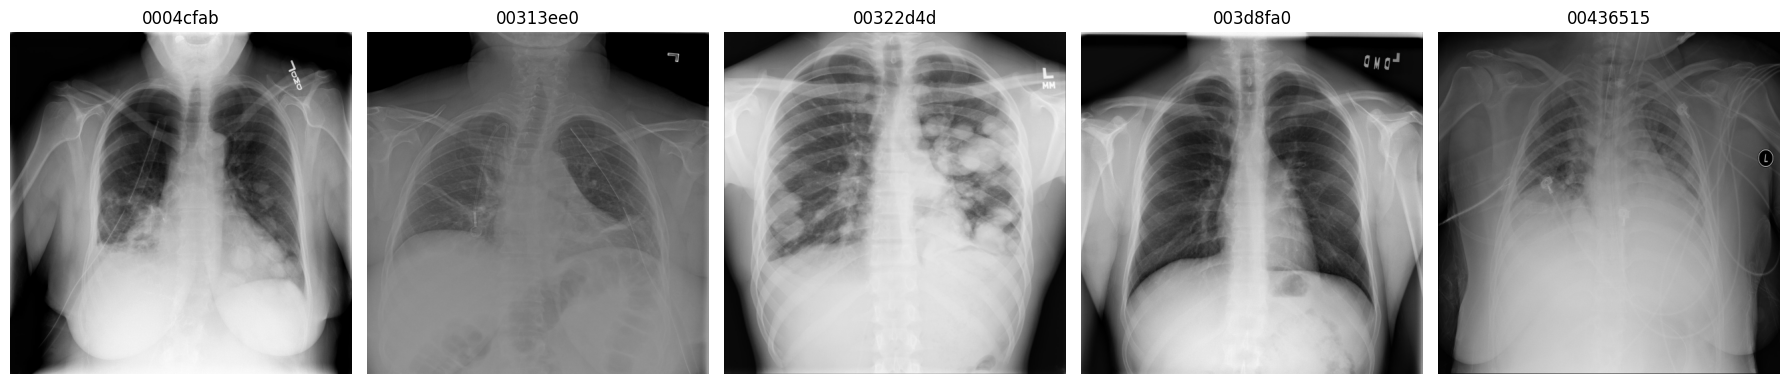

In [16]:
# compruebo que la conversión mantiene la calidad visual y las proporciones correctas
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for ax, pid in zip(axes, ids_test):
    ruta_png = f'{ruta_png_train}/{pid}.png'
    img      = cv2.imread(ruta_png)
    img      = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(pid[:8])
    ax.axis('off')

plt.tight_layout()
plt.show()

# Bucle completo de conversión train

In [17]:

# convierte las  imágenes de train completas
ids_train = df_labels['patientId'].unique()
errores   = []

for pid in tqdm(ids_train, desc='convirtiendo train'):
    ruta_dcm = f'{ruta_train}/{pid}.dcm'
    ruta_png = f'{ruta_png_train}/{pid}.png'
    if os.path.exists(ruta_png):
        continue
    try:
        dicom_a_png(ruta_dcm, ruta_png)
    except Exception as e:
        errores.append((pid, str(e)))

print(f'\nconvertidos: {len(os.listdir(ruta_png_train))}')
print(f'errores:     {len(errores)}')

convirtiendo train:   0%|          | 0/26684 [00:00<?, ?it/s]


convertidos: 26684
errores:     0


# Bucle completo de conversión test

In [18]:
ruta_test       = f'{RUTA_DATOS}/stage_2_test_images'
ruta_png_test   = os.path.join(RUTA_OUTPUTS, 'png_test')
os.makedirs(ruta_png_test, exist_ok=True)

ids_test_full = [f.replace('.dcm', '') for f in os.listdir(ruta_test)]
errores_test  = []

for pid in tqdm(ids_test_full, desc='convirtiendo test'):
    ruta_dcm = f'{ruta_test}/{pid}.dcm'
    ruta_png = f'{ruta_png_test}/{pid}.png'
    if os.path.exists(ruta_png):
        continue
    try:
        dicom_a_png(ruta_dcm, ruta_png)
    except Exception as e:
        errores_test.append((pid, str(e)))

print(f'\nconvertidos: {len(os.listdir(ruta_png_test))}')
print(f'errores:     {len(errores_test)}')

convirtiendo test:   0%|          | 0/3000 [00:00<?, ?it/s]


convertidos: 3000
errores:     0
